In [1]:
import zipfile

zip_file_path = '/content/abalone.zip'
output_directory = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_directory)

print(f"'{zip_file_path}' unzipped to '{output_directory}' successfully.")


'/content/abalone.zip' unzipped to '/content/' successfully.


Original DataFrame head:
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  

Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 

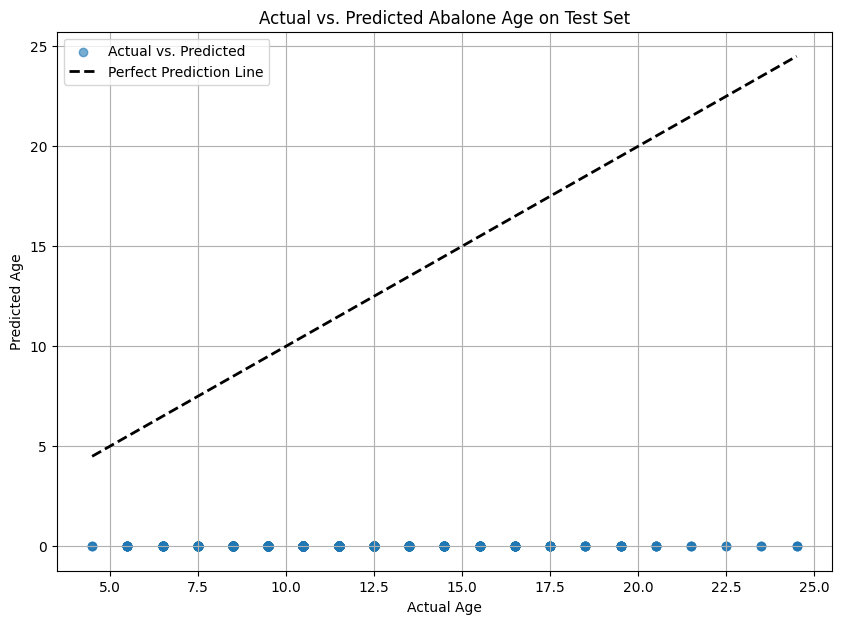

Model evaluation and visualization completed.


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


column_names = [
    'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
    'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'
]


df = pd.read_csv('/content/abalone.data', names=column_names)

print("Original DataFrame head:")
print(df.head())
print("\nOriginal DataFrame info:")
df.info()

df['Age'] = df['Rings'] + 1.5
df = df.drop('Rings', axis=1)

categorical_features = ['Sex']
numerical_features = [
    'Length', 'Diameter', 'Height', 'Whole_weight',
    'Shucked_weight', 'Viscera_weight', 'Shell_weight'
]


df_categorical = pd.get_dummies(df[categorical_features], drop_first=True).astype(int)


scaler = StandardScaler()
df_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(df[numerical_features]),
    columns=numerical_features,
    index=df.index
)

X = pd.concat([df_categorical, df_numerical_scaled], axis=1)
y = df['Age']

print("\nPreprocessed features (X) head:")
print(X.head())
print("\nTarget variable (y) head:")
print(y.head())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data loaded, preprocessed, and split successfully.")
import numpy as np

def relu(x):
    """Rectified Linear Unit (ReLU) activation function."""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of the ReLU activation function."""
    return (x > 0).astype(float)

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of the Sigmoid activation function."""
    s = sigmoid(x)
    return s * (1 - s)

def mse_loss(y_true, y_pred):
    """Mean Squared Error (MSE) loss function."""
    return np.mean((y_true - y_pred)**2)

def mse_loss_derivative(y_true, y_pred):
    """Derivative of the MSE loss function with respect to predictions."""
    return 2 * (y_pred - y_true) / y_true.size

print("Activation functions and MSE loss functions defined successfully.")
class MLP:
    def __init__(self, layer_dims, learning_rate=0.01, activation_func_hidden=relu,
                 activation_func_hidden_derivative=relu_derivative, output_activation=None):
        self.layer_dims = layer_dims
        self.learning_rate = learning_rate
        self.activation_func_hidden = activation_func_hidden
        self.activation_func_hidden_derivative = activation_func_hidden_derivative
        self.output_activation = output_activation
        self.parameters = {}
        self.initialize_parameters()

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.layer_dims)):
            self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * 0.01
            self.parameters[f'b{l}'] = np.zeros((self.layer_dims[l], 1))

    def forward(self, X):
        cache = {}
        A = X.T
        cache['A0'] = A

        for l in range(1, len(self.layer_dims)):
            A_prev = A
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']

            Z = np.dot(W, A_prev) + b
            cache[f'Z{l}'] = Z

            if l == len(self.layer_dims) - 1:
                A = Z
            else:
                A = self.activation_func_hidden(Z)
            cache[f'A{l}'] = A

        return A, cache

    def backward(self, X, y_true, y_pred, cache):
        m = X.shape[0]
        y_true = y_true.reshape(1, -1)
        y_pred = y_pred.reshape(1, -1)


        dA_prev = mse_loss_derivative(y_true, y_pred)

        for l in reversed(range(1, len(self.layer_dims))):
            Z = cache[f'Z{l}']
            A_prev_from_cache = cache[f'A{l-1}']

            if l == len(self.layer_dims) - 1:
                dZ = dA_prev
            else:
                dZ = dA_prev * self.activation_func_hidden_derivative(Z)

            dW = (1 / m) * np.dot(dZ, A_prev_from_cache.T)
            db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)


            self.parameters[f'W{l}'] -= self.learning_rate * dW
            self.parameters[f'b{l}'] -= self.learning_rate * db


            W_current = self.parameters[f'W{l}']
            dA_prev = np.dot(W_current.T, dZ)

    def predict(self, X):

        predictions, _ = self.forward(X)

        return predictions.T.flatten()

print("MLP class defined successfully.")
input_dim = X_train.shape[1]
output_dim = 1
hidden_layer_dim = 64


layer_dims = [input_dim, hidden_layer_dim, output_dim]


mlp = MLP(
    layer_dims=layer_dims,
    learning_rate=0.001,
    activation_func_hidden=relu,
    activation_func_hidden_derivative=relu_derivative
)

epochs = 1000
losses = []


X_train_np = X_train.values.astype(float)
y_train_np = y_train.values.astype(float)

print("Starting MLP training...")
for i in range(epochs):

    y_pred_train, cache = mlp.forward(X_train_np)

    # Calculate loss
    loss = mse_loss(y_train_np, y_pred_train.T.flatten())
    losses.append(loss)


    mlp.backward(X_train_np, y_train_np, y_pred_train.T.flatten(), cache)

    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss:.4f}")

print("MLP training finished.")
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X_test_np = X_test.values.astype(float)
y_test_np = y_test.values.astype(float)


y_pred_test = mlp.predict(X_test_np)

mae = mean_absolute_error(y_test_np, y_pred_test)
r2 = r2_score(y_test_np, y_pred_test)

print(f"Mean Absolute Error (MAE) on test set: {mae:.4f}")
print(f"R-squared (R2) on test set: {r2:.4f}")


plt.figure(figsize=(10, 7))
plt.scatter(y_test_np, y_pred_test, alpha=0.6, label='Actual vs. Predicted')
plt.plot([min(y_test_np), max(y_test_np)], [min(y_test_np), max(y_test_np)], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs. Predicted Abalone Age on Test Set')
plt.legend()
plt.grid(True)
plt.show()

print("Model evaluation and visualization completed.")